# Formatos de Datos para Big Data

## ¿Por qué importan los formatos de datos?

En el mundo del Big Data, elegir el formato correcto para almacenar datos es tan importante como tener una buena arquitectura. Los formatos determinan:

- **Velocidad de lectura/escritura**: ¿Cuán rápido podemos acceder a los datos?
- **Espacio de almacenamiento**: ¿Cuánto nos cuesta guardar los datos?
- **Compatibilidad**: ¿Con qué herramientas puedo trabajar?
- **Escalabilidad**: ¿Puedo procesar millones de registros eficientemente?

## Formatos más usados:

- **Avro**: Formato binario orientado a **filas**, ideal para streaming en tiempo real
- **Parquet**: Formato columnar optimizado para **analítica**, excelente compresión
- **ORC**: Formato columnar diseñado para **Hadoop/Hive**, máxima eficiencia

**Fuente**: [Formatos de datos en Big Data - Aitor Medrano](https://aitor-medrano.github.io/iabd/de/formatos.html)


## Propiedades de los Formatos de Datos

Un buen formato de datos para Big Data debe ser:

1. **Independiente del lenguaje**: Usable desde Python, Java, Scala, etc.
2. **Expresivo**: Soporte para estructuras complejas y anidadas
3. **Eficiente**: Rápido y reducido en tamaño
4. **Dinámico**: Permitir definir nuevos tipos de datos
5. **Splittable**: Poder dividirse en fragmentos para procesamiento paralelo

### Filas vs Columnas

**Formatos basados en filas (Row-based)**:
- CSV, Avro, JSON
- Mejores para escrituras
- Óptimos cuando se necesitan todos los campos de un registro

**Formatos basados en columnas (Columnar)**:
- Parquet, ORC
- Mejores para lecturas analíticas
- Óptimos para consultas sobre subconjunto de columnas
- Mejor compresión (datos del mismo tipo juntos)


---

## CONCEPTOS TEÓRICOS FUNDAMENTALES

### 1. Serialización y Deserialización

**Definición**: La serialización es el proceso de convertir objetos en memoria en un formato que pueda ser:
- Almacenado en disco
- Transmitido por red
- Intercambiado entre sistemas

**Proceso:**
```
Objeto en Python (en memoria)
        ↓
    SERIALIZACIÓN
        ↓
Datos en disco (bytes)
        ↓
    DESERIALIZACIÓN (otro programa)
        ↓
Objeto en Java/Scala/Go (en memoria)
```

**Analógía**: Como empacar un regalo
- Objeto en memoria = Regalo sin empacar
- Serialización = Meter en caja, sellar
- Deserialización = Abrir caja en destino

**Importancia**:
- CSV: Serialización trivial (solo texto)
- Avro: Serialización con esquema (validación)
- Parquet: Serialización columnar (compresión)

### 2. Formato Binario vs Texto

**Texto (CSV, JSON)**:
```
Datos: [1, 2, 3, 4, 5]
CSV: "1,2,3,4,5"        (bytes: 1,2,3,4,5,text,commas) = 10 bytes
```

**Binario (Avro, Parquet)**:
```
Datos: [1, 2, 3, 4, 5]
Binario: 0x01 0x02 0x03 0x04 0x05 = 5 bytes (directo)
```

**Ventaja binario**: Compacto, más rápido, sin ambigüedad

**Desventaja binario**: No legible para humanos (necesitas herramientas)

### 3. Compresión: Teoría de la Información

**Concepto**: Reducir tamaño detectando patrones y redundancia

**Ejemplo práctico**:
```
SIN COMPRESIÓN:
"Juan,30,IT,3000"
"Maria,28,HR,3500"
"Pedro,35,IT,4000"
"Laura,32,IT,3800"
"Carlos,29,HR,3200"
= 80 bytes

CON COMPRESIÓN (detecta patrones):
- "IT" aparece 3 veces → reemplazar con código 0x01
- "HR" aparece 2 veces → reemplazar con código 0x02
- Números pequeños tienen patrón → usar variable-length encoding

Resultado comprimido:
"Juan,30,0x01,3000"... 
= 50 bytes (37% ahorro)

PARQUET COLUMNAR HACE ESTO MEJOR:
Todos los "IT" juntos, todos los salarios juntos
= Patrones aún más evidentes
= Hasta 80% compresión
```

**Tipos de compresión**:
- SNAPPY: Balance velocidad/compresión
- GZIP: Máxima compresión, más lento
- LZ4: Máxima velocidad, menos compresión

### 4. Lectura Secuencial vs Acceso Aleatorio

**Lectura Secuencial** (archivos de texto):
```
CSV: "nombre,edad,salario"
Para leer la fila 1000000, debo leer:
1. fila 1
2. fila 2
3. ...
4. fila 999999
5. fila 1000000

Tiempo: O(n) - proporcional al número de filas
```

**Acceso Aleatorio** (formatos columnares con índices):
```
Parquet con índices:
Para leer la fila 1000000, tengo metadatos:
- "Fila 1000000 está en bloque 15"
- Ir directamente al bloque 15

Tiempo: O(log n) - logarítmico
```

**Importancia**: Parquet es orders of magnitude más rápido para queries específicas

### 5. Row Groups y Column Chunks (Arquitectura Parquet)

**Concepto**: Parquet divide el archivo en unidades manejables

```
ARCHIVO PARQUET (1 billón de registros):
├── ROW GROUP 1 (filas 1-1,000,000)
│   ├── COLUMN CHUNK para "nombre" (comprimido)
│   ├── COLUMN CHUNK para "edad" (comprimido)
│   └── COLUMN CHUNK para "salario" (comprimido)
│
├── ROW GROUP 2 (filas 1,000,001-2,000,000)
│   ├── COLUMN CHUNK para "nombre"
│   ├── COLUMN CHUNK para "edad"
│   └── COLUMN CHUNK para "salario"
│
└── METADATOS GLOBALES:
    ├── Esquema
    ├── Índices de Row Groups
    ├── Estadísticas (min/max por columna)
    └── Ubicación de cada chunk
```

**Ventaja**: Puedo leer SOLO el Row Group y SOLO el Column que necesito

### 6. Predicado Pushdown (Query Optimization)

**Sin Pushdown** (lo que hace SQL mal):
```sql
SELECT * FROM datos.parquet
WHERE salario > 5000 AND año = 2024

PROCESO:
1. Leer TODAS las filas
2. Leer TODAS las columnas
3. Aplicar filtro salario > 5000
4. Aplicar filtro año = 2024
```

**Con Pushdown** (lo que hace Spark bien):
```sql
SELECT * FROM datos.parquet
WHERE salario > 5000 AND año = 2024

PROCESO (gracias a Parquet):
1. Leer metadatos: "año=2024 está en Row Groups 5,6,7"
2. Saltar Row Groups 1-4
3. En Row Groups 5-7, leer metadatos: 
   "salarios: min=3000, max=6000"
4. Como max(salario)=6000 > 5000, leer esos chunks
5. Aplicar filtro final

RESULTADO: Lee solo 30% de los datos
```

**Importancia**: Queries 10-100x más rápidas

### 7. Evolución de Esquemas (Avro Advantage)

**Problema sin esquema**:
```csv
nombre,edad,salario
Juan,30,3000
Maria,28,3500
```

Meses después, agregan "departamento":
```csv
nombre,edad,salario,departamento
Juan,30,3000,IT
Maria,28,3500,
```

¿Qué pasó con datos antiguos? ¿Está vacío o no existe?

**Solución con Avro**:
```json
{
  "name": "Empleado",
  "type": "record",
  "fields": [
    {"name": "nombre", "type": "string"},
    {"name": "edad", "type": "int"},
    {"name": "salario", "type": "float"},
    {"name": "departamento", "type": ["null", "string"], "default": null}
  ]
}
```

Nuevo campo tiene "default": null
- Datos antiguos automáticamente tienen departamento=null
- Compatibilidad perfecta

**Importancia**: Critical para systems que evolucionan


## Instalación de dependencias

Primero instalamos las librerías necesarias:


In [2]:
%pip install pandas pyarrow fastavro faker matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\Giralte\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## ¿Qué librerías necesitamos?

Vamos a importar las siguientes librerías:

| Librería | Qué hace | Por qué |
|----------|----------|--------|
| `pandas` | Manipulación de datos en DataFrames | Base de todo análisis de datos |
| `pyarrow` | Soporte para Parquet y ORC | Formatos columnares modernos |
| `fastavro` | Lectura/escritura de archivos Avro | Formato de streaming |
| `faker` | Genera datos fake realistas | Para nuestros ejemplos |
| `matplotlib` / `seaborn` | Visualización de datos | Para mostrar resultados |



In [3]:
import pandas as pd
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
import pyarrow.orc as orc
import fastavro
import os
import time
import json
from faker import Faker
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
print("Librerías importadas correctamente")


Librerías importadas correctamente


## GUÍA DE LECTURA: Cómo entender los formatos

Antes de empezar, entendamos la diferencia fundamental:

### Arquitectura: Filas vs Columnas

#### **Formato FILAS (Row-based): CSV, Avro**
```
Los datos se almacenan línea por línea:

FILA 1: [Juan,   30, Vendedor, 3000]
FILA 2: [María,  28, Manager,  3500]
FILA 3: [Pedro,  35, Director, 4000]

 VENTAJAS:
  • Lectura/escritura rápidas
  • Ideal para streaming (tiempo real)
  • Perfecto para OLTP (transacciones)
  • Fácil de entender

 DESVENTAJAS:
  • Mala compresión (100-200 MB)
  • Lectura lenta si solo necesitas 1 columna
  • Alto costo en almacenamiento cloud
```

#### **Formato COLUMNAS (Columnar): Parquet, ORC**
```
Los datos se almacenan columna por columna:

COLUMNA NOMBRES: [Juan, María, Pedro]
COLUMNA EDAD:    [30, 28, 35]
COLUMNA PUESTO:  [Vendedor, Manager, Director]
COLUMNA SUELDO:  [3000, 3500, 4000]

VENTAJAS:
  • Compresión excelente (10-30 MB - 80% ahorro!)
  • Lectura ULTRARRÁPIDA si solo necesitas 1-2 columnas
  • Perfecto para analítica (OLAP)
  • Bajo costo en almacenamiento cloud
 DESVENTAJAS:
  • Escritura más lenta
  • Menos ideal para streaming
  • Requiere leer bloques completos
```

###  Analogía del mundo real

Imagina una tienda con 1 millón de productos:

**Formato FILAS (Avro)**: Los productos están en una larga lista
- Para contar cuántos productos hay: **Rápido** 
- Para saber qué productos son rojo: **Lento** (lees 1 millón de líneas) 

**Formato COLUMNAS (Parquet)**: Todos los colores están juntos, todos los precios juntos
- Para contar cuántos productos hay: **Normal**
- Para saber qué productos son rojo: **ULTRARRÁPIDO** 
- Ocupa 10x menos espacio: **Ultrabarato** 


---

# 1 FORMATO AVRO - El Formato de Streaming

## ¿Qué es AVRO?

Apache Avro es un formato de **serialización de datos** diseñado por Hadoop para:
-  **Comunicación entre sistemas** (Kafka, APIs, microservicios)
-  **Almacenamiento binario compacto** (como CSV pero más pequeño)
-  **Evolución de esquemas** (puedes agregar campos sin romper compatibilidad)

### Conceptos Clave: El "Esquema"

Antes de guardar datos en Avro, necesitas definir un **esquema** (estructura):

```json
{
  "name": "Empleado",           // Nombre del tipo
  "type": "record",             // Es un registro (fila)
  "fields": [                   // Lista de campos
    {"name": "nombre", "type": "string"},    // Texto
    {"name": "edad", "type": "int"},         // Número entero
    {"name": "salario", "type": "float"}     // Número decimal
  ]
}
```

**¿Por qué es importante?**
-  Valida que los datos sean correctos ANTES de guardar
-  Permite evolución: puedes agregar campos con valores por defecto
-  Otros sistemas saben exactamente qué esperar al leer el archivo

### Analogía: Esquema = Molde de pastel

```
Sin esquema (CSV):        Con esquema (Avro):
juan,30,3000          →   "Juan, 30, 3000 es válido?"
maria,28,abc          →    Error: 'abc' no es número
pedro,35,4000         →    Correcto

AVRO RECHAZA DATOS INVÁLIDOS
```

### Ventajas de AVRO

| Aspecto | Ventaja |
|---------|---------|
| **Tamaño** | Binario comprimido (30-40% compresión) |
| **Velocidad** | Rápido para streaming |
| **Esquema** | Evoluciona sin romper compatibilidad |
| **Streaming** | Perfecto para Kafka, Pulsar |
| **Ecosistema** | Ampliamente soportado |

### Desventajas de AVRO

| Aspecto | Desventaja |
|---------|-----------|
| **Compresión** | No es tan compacto como Parquet (60% vs 80%) |
| **Analítica** | Pobre para queries selectivas |
| **Visualización** | Necesitas herramientas especiales |


---

## OPTIMIZACIÓN: Spark Query Execution

### Plan de Ejecución: Logical vs Physical

Cuando ejecutas una query en Spark, pasa por varias etapas:

**1. Logical Plan** (lo que DEBERÍAS hacer):
```sql
SELECT nombre, salario 
FROM empleados
WHERE salario > 5000 AND año = 2024
ORDER BY salario DESC
```

Spark lo entiende como:
```
Logical Plan:
├── Sort por salario DESC
├── Filter salario > 5000
├── Filter año = 2024
├── Project [nombre, salario]
└── Scan empleados
```

**2. Optimized Logical Plan** (lo inteligente):
```
Optimized Plan:
├── Sort por salario DESC
├── Project [nombre, salario]
└── Filter (salario > 5000 AND año = 2024)  ← Se mueve abajo!
    └── Scan empleados
```

**Por qué cambió**: El filter se aplica ANTES del project
- Lee menos columnas de disco
- Menos filas que procesar después

**3. Physical Plan** (cómo lo ejecuta):
```
Physical Plan:
├── SortAggregate [salario DESC]
├── Project [nombre, salario]
├── Filter (salario > 5000 AND año = 2024)
├── ParquetScan (año=2024 partition pruning)
   └── Lee SOLO carpeta año=2024
```

**Optimización final**: Parquet dice "busca solo año=2024"
- Ignora año=2023, 2025, etc.
- Lee 24x menos datos


## 1. Formato AVRO

**Apache Avro** es un formato binario orientado a filas que:
- Usa JSON para definir esquemas
- Serializa datos en formato binario compacto
- Excelente para evolución de esquemas
- Ideal para streaming con Kafka

### Estructura de un archivo Avro

Un archivo Avro contiene:
1. **Cabecera**: metadatos y esquema en JSON
2. **Bloques de datos**: datos serializados
3. **Marcador de sincronización**: para dividir el archivo


In [4]:
# Definir un esquema Avro
schema_avro = {
    'name': 'Empleado',
    'type': 'record',
    'fields': [
        {'name': 'nombre', 'type': 'string'},
        {'name': 'edad', 'type': 'int'},
        {'name': 'departamento', 'type': 'string'},
        {'name': 'salario', 'type': 'float'}
    ]
}

# Lista de nombres proporcionados
nombres = [
    'Alejandro', 'Marcos', 'Óscar', 'Lucian', 'Siro', 'Iñigo',
    'Andrews', 'Sheimae', 'Mario', 'Ignacio', 'Javier', 'Alonso',
    'Dilan', 'Adnan', 'Iñigo Samuel', 'Sergio', 'Alvaro',
    'Ethan', 'Santiago', 'Marta', 'Jaime', 'Borja', 'Jorge',
     'Rincon','Ángel'
]

# Generar datos de ejemplo con edades entre 19 y 25
import random
random.seed(42)  # Para reproducibilidad

departamentos = ['IT', 'Ventas', 'Marketing', 'RRHH', 'Finanzas']
empleados = []

for nombre in nombres:
    empleado = {
        'nombre': nombre,
        'edad': random.randint(19, 25),
        'departamento': random.choice(departamentos),
        'salario': round(random.uniform(20000, 35000), 2)
    }
    empleados.append(empleado)

# Escribir archivo Avro
with open('empleados.avro', 'wb') as out:
    fastavro.writer(out, schema_avro, empleados)

print("Archivo Avro creado")
print(f"Total de empleados: {len(empleados)}")
print(f"Tamaño: {os.path.getsize('empleados.avro')} bytes")
print(f"\nPrimeros 5 empleados:")
for emp in empleados[:5]:
    print(f"  - {emp['nombre']}, {emp['edad']} años, {emp['departamento']}, ${emp['salario']:,.2f}")


Archivo Avro creado
Total de empleados: 25
Tamaño: 743 bytes

Primeros 5 empleados:
  - Alejandro, 24 años, IT, $20,375.16
  - Marcos, 21 años, Ventas, $23,348.16
  - Óscar, 24 años, IT, $30,150.49
  - Lucian, 23 años, IT, $28,857.39
  - Siro, 19 años, IT, $21,405.43


In [5]:
# Leer archivo Avro
with open('empleados.avro', 'rb') as fo:
    for record in fastavro.reader(fo):
        print(record)


{'nombre': 'Alejandro', 'edad': 24, 'departamento': 'IT', 'salario': 20375.16015625}
{'nombre': 'Marcos', 'edad': 21, 'departamento': 'Ventas', 'salario': 23348.16015625}
{'nombre': 'Óscar', 'edad': 24, 'departamento': 'IT', 'salario': 30150.490234375}
{'nombre': 'Lucian', 'edad': 23, 'departamento': 'IT', 'salario': 28857.390625}
{'nombre': 'Siro', 'edad': 19, 'departamento': 'IT', 'salario': 21405.4296875}
{'nombre': 'Iñigo', 'edad': 20, 'departamento': 'Finanzas', 'salario': 29030.279296875}
{'nombre': 'Andrews', 'edad': 23, 'departamento': 'Ventas', 'salario': 30740.2890625}
{'nombre': 'Sheimae', 'edad': 24, 'departamento': 'Finanzas', 'salario': 26292.80078125}
{'nombre': 'Mario', 'edad': 22, 'departamento': 'Finanzas', 'salario': 24172.859375}
{'nombre': 'Ignacio', 'edad': 25, 'departamento': 'IT', 'salario': 31382.109375}
{'nombre': 'Javier', 'edad': 20, 'departamento': 'RRHH', 'salario': 25103.759765625}
{'nombre': 'Alonso', 'edad': 20, 'departamento': 'Ventas', 'salario': 3435

---

# 2 FORMATO PARQUET - El Rey de la Analítica

## ¿Qué es PARQUET?

Apache Parquet es el formato **columnar** preferido por:
-  **Data Scientists**: Compresión increíble (80% de ahorro)
-  **Data Engineers**: Lectura ULTRARRÁPIDA (solo lee columnas que necesita)
-  **CFOs**: Costos de almacenamiento mínimos
-  **Todos**: Integración perfecta con Spark, Athena, BigQuery

### ¿Cómo funciona la "magia" de Parquet?

**Idea clave**: Guardar "columna por columna" en lugar de "fila por fila"

```
DATOS ORIGINALES (FILAS):
┌──────┬─────┬─────┬────────┐
│Nombre│Edad │Puest│Salario │
├──────┼─────┼─────┼────────┤
│Juan  │30   │Vend │3000    │
│María │28   │Mgr  │3500    │
│Pedro │35   │Dir  │4000    │
└──────┴─────┴─────┴────────┘

GUARDADO EN PARQUET (COLUMNAS):
┌──────────────────┐
│[Juan, María,Pedro]│ ← Nombres (texto)
│30,28,35          │ ← Edades (números)
│3000,3500,4000    │ ← Salarios (números)
└──────────────────┘

VENTAJA: Los números se comprimen JUNTOS (80% de ahorro)
```

### Compresión: Por qué funciona tan bien

**Problema con CSV:**
```
juan,30,vendedor,3000
maria,28,manager,3500
pedro,35,director,4000

Tamaño: 80 caracteres (cada carácter = 1 byte) = 80 bytes
```

**Solución con Parquet:**
```
Columna NOMBRES: [juan, maría, pedro]
  → Detecta patrones: todos tienen 4-5 caracteres
  → Los comprime a 6 bytes
  
Columna EDADES: [30, 28, 35]
  → Detecta: todos números pequeños (0-100)
  → Los comprime a 2 bytes

Columna SALARIOS: [3000, 3500, 4000]
  → Detecta: números similares
  → Los comprime a 4 bytes

Total Parquet: ~12 bytes (¡85% de ahorro!)
```

### Estructura Interna de Parquet

Parquet es como un "almacén organizado":

```
┌─────────────────────────────────────────┐
│         ARCHIVO PARQUET                 │
├─────────────────────────────────────────┤
│ Row Group 1 (filas 1-1000)              │
│  ├─ Column 1 (nombre): comprimida       │
│  ├─ Column 2 (edad): comprimida         │
│  └─ Column 3 (salario): comprimida      │
│                                         │
│ Row Group 2 (filas 1001-2000)           │
│  ├─ Column 1: comprimida                │
│  ├─ Column 2: comprimida                │
│  └─ Column 3: comprimida                │
│                                         │
│ METADATOS:                              │
│  ├─ Esquema: qué columnas existen       │
│  ├─ Estadísticas: min/max de cada col   │
│  └─ Ubicación: dónde está cada columna  │
└─────────────────────────────────────────┘

VENTAJA: Puedes leer SOLO la columna "salario" sin tocar "nombre" ni "edad"
```

### Ventajas de PARQUET

| Aspecto | Ventaja |
|---------|---------|
| **Compresión** |  LA MEJOR: 80% de ahorro típico |
| **Lectura selectiva** |  ULTRARRÁPIDA para queries específicas |
| **Almacenamiento** |  Costos minimizados en cloud |
| **Herramientas** | Soportado por todos (Spark, Athena, etc.) |
| **Análisis** | Perfecto para data science |
| **Esquema** | Almacena esquema automáticamente |

### Desventajas de PARQUET

| Aspecto | Desventaja |
|---------|-----------|
| **Escritura** | Más lenta que CSV (compresión cuesta CPU) |
| **Streaming** | No ideal para datos en tiempo real |
| **Pequeños datasets** | Overhead no vale la pena (<100MB) |


### Avro con compresión

Avro soporta diferentes códecs de compresión:
- **null**: sin compresión
- **deflate**: compresión estándar (zlib) - recomendado por compatibilidad
- **snappy**: compresión rápida (requiere librería `cramjam`)
- **bzip2**: máxima compresión

**Nota**: Para usar Snappy, instala: `pip install cramjam`


In [7]:
# Escribir con compresión Deflate (alternativa a Snappy que no requiere librerías adicionales)
with open('empleados_deflate.avro', 'wb') as out:
    fastavro.writer(out, schema_avro, empleados, codec='deflate')

print("Archivo Avro con Deflate creado")
print(f"Sin compresión: {os.path.getsize('empleados.avro')} bytes")
print(f"Con Deflate: {os.path.getsize('empleados_deflate.avro')} bytes")


Archivo Avro con Deflate creado
Sin compresión: 743 bytes
Con Deflate: 649 bytes


---

# 3 FORMATO ORC - El Campeón de Hive

## ¿Qué es ORC?

**ORC** = **O**ptimized **R**ow **C**olumnar

Es como Parquet, pero optimizado específicamente para Hadoop/Hive:
- ✅ **Creado por Facebook** para sus enormes data warehouses
- ✅ **Integración perfecta con Hive** (SQL en Hadoop)
- ✅ **Compresión comparable a Parquet** (75-85% de ahorro)
- ✅ **Índices incorporados** (más rápido que Parquet en algunos casos)

### ORC vs Parquet: ¿Cuál elegir?

```
┌──────────────────┬─────────────────────┬─────────────────────┐
│ Característica   │ PARQUET             │ ORC                 │
├──────────────────┼─────────────────────┼─────────────────────┤
│ Compresión       │  80% (excelente)    │ 75% (excelente)     │
│ Velocidad        │  Muy rápido         │ Rápido              │
│ Índices          │  No                 │   Sí                │
│ Ecosistema       │  Todos: Spark,      │ Especializado: Hive │
│                  │   BigQuery, etc.    │                     │
│ Hadoop nativo    │  Bueno              │     Diseñado para   │
│ Herramientas     │  Más opciones       │ Menos opciones      │
│ Facilidad        │  Simple             │ Más complejo        │
│ Documentación    │  Abundante          │ Moderada            │
└──────────────────┴─────────────────────┴─────────────────────┘
```

### Ventajas de ORC

| Aspecto | Ventaja |
|---------|---------|
| **Compresión** | 75-85% de ahorro (comparado con CSV) |
| **Índices** | Includes built-in ACID transactions |
| **Hive** |  Optimizado para Hive SQL |
| **Performance** |  Muy rápido en queries complejas |
| **Metadatos** | Estadísticas precisas por columna |

### Desventajas de ORC

| Aspecto | Desventaja |
|---------|-----------|
| **Compatibilidad** | Menos soportado que Parquet |
| **Curva aprendizaje** | Más complejo de configurar |
| **Herramientas** | Menos integraciones externas |
| **Streaming** | No es ideal para datos en tiempo real |


## 2. Formato PARQUET

**Apache Parquet** es un formato columnar que:
- Almacena datos por columnas, no por filas
- Optimizado para consultas analíticas
- Excelente compresión
- Integración nativa con Spark y Pandas
- Permite acceder a columnas específicas sin leer todo el archivo

### Estructura de Parquet

Un archivo Parquet contiene:
1. **Row Groups**: conjuntos de filas
2. **Column Chunks**: datos de cada columna por grupo
3. **Páginas**: unidades mínimas de lectura
4. **Metadatos**: estadísticas y esquema


In [8]:
# Crear un DataFrame más grande
fake = Faker('es_ES')
np.random.seed(42)

n_records = 10000
datos_ventas = {
    'fecha': pd.date_range('2024-01-01', periods=n_records, freq='h'),
    'producto': np.random.choice(['Laptop', 'Smartphone', 'Tablet', 'Monitor', 'Teclado'], n_records),
    'cantidad': np.random.randint(1, 20, n_records),
    'precio_unitario': np.random.uniform(50, 1500, n_records).round(2),
    'cliente': [fake.name() for _ in range(n_records)],
    'ciudad': [fake.city() for _ in range(n_records)]
}

df_ventas = pd.DataFrame(datos_ventas)
df_ventas['total'] = (df_ventas['cantidad'] * df_ventas['precio_unitario']).round(2)

print(f"DataFrame creado con {len(df_ventas):,} registros")
print(df_ventas.head())


DataFrame creado con 10,000 registros
                fecha producto  cantidad  precio_unitario  \
0 2024-01-01 00:00:00  Monitor         7           229.45   
1 2024-01-01 01:00:00  Teclado         4           166.06   
2 2024-01-01 02:00:00   Tablet         7          1145.47   
3 2024-01-01 03:00:00  Teclado         4            63.78   
4 2024-01-01 04:00:00  Teclado        12          1440.56   

                       cliente       ciudad     total  
0            Horacio de Macias      Badajoz   1606.15  
1         Albert Roldán Garcia     Asturias    664.24  
2                 Sonia Fuster   Pontevedra   8018.29  
3          Bruno Goñi-Bautista      Sevilla    255.12  
4  Jafet Pío Armengol Paniagua  Guadalajara  17286.72  


In [9]:
# Guardar en diferentes formatos
inicio = time.time()
df_ventas.to_csv('ventas.csv', index=False)
tiempo_csv = time.time() - inicio

inicio = time.time()
df_ventas.to_parquet('ventas.parquet', compression='snappy')
tiempo_parquet = time.time() - inicio

inicio = time.time()
df_ventas.to_parquet('ventas_gzip.parquet', compression='gzip')
tiempo_parquet_gzip = time.time() - inicio

# Comparar tamaños
print("\nComparación de tamaños y tiempos de escritura:\n")
print(f"CSV:                    {os.path.getsize('ventas.csv'):>12,} bytes | {tiempo_csv:.3f}s")
print(f"Parquet (Snappy):       {os.path.getsize('ventas.parquet'):>12,} bytes | {tiempo_parquet:.3f}s")
print(f"Parquet (Gzip):         {os.path.getsize('ventas_gzip.parquet'):>12,} bytes | {tiempo_parquet_gzip:.3f}s")

print(f"\nAhorro con Parquet Snappy: {(1 - os.path.getsize('ventas.parquet')/os.path.getsize('ventas.csv'))*100:.1f}%")
print(f"Ahorro con Parquet Gzip:   {(1 - os.path.getsize('ventas_gzip.parquet')/os.path.getsize('ventas.csv'))*100:.1f}%")



Comparación de tamaños y tiempos de escritura:

CSV:                         779,867 bytes | 0.065s
Parquet (Snappy):            419,922 bytes | 0.031s
Parquet (Gzip):              303,079 bytes | 0.084s

Ahorro con Parquet Snappy: 46.2%
Ahorro con Parquet Gzip:   61.1%


In [18]:
# Leer solo columnas específicas (ventaja de formato columnar)
inicio = time.time()
df_csv_columnas = pd.read_csv('ventas.csv', usecols=['producto', 'total'])
tiempo_csv_lectura = time.time() - inicio

inicio = time.time()
df_parquet_columnas = pd.read_parquet('ventas.parquet', columns=['producto', 'total'])
tiempo_parquet_lectura = time.time() - inicio

print("\nComparación de velocidad de lectura (solo 2 columnas):\n")
print(f"CSV:     {tiempo_csv_lectura:.4f}s")
print(f"Parquet: {tiempo_parquet_lectura:.4f}s")
print(f"\nParquet es {tiempo_parquet_lectura/tiempo_csv_lectura:.4f}x más rápido")



Comparación de velocidad de lectura (solo 2 columnas):

CSV:     0.0099s
Parquet: 0.0038s

Parquet es 0.3867x más rápido


## 3. Formato ORC

**Apache ORC** (Optimized Row Columnar) es:
- Similar a Parquet pero optimizado para Hive
- Formato columnar con alta compresión
- Incluye índices y estadísticas por defecto
- Mejor integración con el ecosistema Hadoop

** Nota importante para Windows**: ORC puede tener problemas con zonas horarias en Windows. Si encuentras errores, es un problema conocido de PyArrow. En ese caso, usa Parquet como alternativa.


In [20]:
# Guardar en formato ORC
# NOTA: Si estás en Windows y obtienes errores de zona horaria, salta esta celda
# ORC tiene problemas conocidos con fechas en Windows

try:
    # Crear una copia del DataFrame sin columna de fecha para evitar problemas
    df_ventas_orc = df_ventas.copy()
    df_ventas_orc['fecha'] = df_ventas_orc['fecha'].dt.tz_localize(None)  # Quitar timezone
    
    inicio = time.time()
    df_ventas_orc.to_orc('ventas.orc')
    tiempo_orc = time.time() - inicio
    
    inicio = time.time()
    df_ventas_orc.to_orc('ventas_zlib.orc', engine_kwargs={"compression": 'zlib'})
    tiempo_orc_zlib = time.time() - inicio
    
    print("\nComparación con ORC:\n")
    print(f"ORC (sin compresión):   {os.path.getsize('ventas.orc'):>12,} bytes | {tiempo_orc:.3f}s")
    print(f"ORC (zlib):             {os.path.getsize('ventas_zlib.orc'):>12,} bytes | {tiempo_orc_zlib:.3f}s")
    orc_available = True
except Exception as e:
    print(f"\n Error al crear archivos ORC: {str(e)}")
    print("Esto es común en Windows. ORC será omitido en las comparaciones.")
    orc_available = False



Comparación con ORC:

ORC (sin compresión):        559,411 bytes | 0.010s
ORC (zlib):                  224,131 bytes | 0.019s


### Solución al error de ORC en Windows

Si obtuviste el error de zona horaria con ORC, ejecuta la siguiente celda para solucionarlo:


In [19]:
# SOLUCIÓN para el error de ORC en Windows
# Este error ocurre porque PyArrow ORC busca archivos de zona horaria en rutas de Linux

import os
import sys

# Paso 1: Instalar tzdata si no está instalado (contiene las zonas horarias)
try:
    import tzdata
    print("✓ tzdata ya está instalado")
except ImportError:
    print("Instalando tzdata...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tzdata"])
    import tzdata
    print("✓ tzdata instalado correctamente")

# Paso 2: Configurar la variable de entorno TZDIR
# Apuntar a la carpeta de zonas horarias de tzdata
tzdata_path = os.path.join(os.path.dirname(tzdata.__file__), 'zoneinfo')
os.environ['TZDIR'] = tzdata_path

print(f"\n✓ Variable TZDIR configurada en: {tzdata_path}")
print("\n¡Ahora intenta ejecutar de nuevo la celda de ORC!")
print("Tip: Si sigue fallando, reinicia el kernel y vuelve a ejecutar desde el principio.")


✓ tzdata ya está instalado

✓ Variable TZDIR configurada en: C:\Users\Giralte\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tzdata\zoneinfo

¡Ahora intenta ejecutar de nuevo la celda de ORC!
Tip: Si sigue fallando, reinicia el kernel y vuelve a ejecutar desde el principio.


**Explicación del error y la solución:**

**¿Por qué ocurre el error?**
- PyArrow ORC (librería de Apache Arrow) fue diseñado principalmente para sistemas Linux/Unix
- Busca archivos de zona horaria en `/usr/share/zoneinfo/` que no existe en Windows
- Windows maneja las zonas horarias de forma diferente

**¿Qué hace la solución?**
1. **Instala `tzdata`**: Un paquete de Python que contiene la base de datos IANA de zonas horarias
2. **Configura TZDIR**: Le dice a PyArrow dónde encontrar los archivos de zona horaria en Windows
3. **Usa la ruta correcta**: Apunta a la carpeta `zoneinfo` dentro de `tzdata`

**Alternativa si persiste el problema:**
Si después de ejecutar la solución sigue fallando:
- Reinicia el kernel del notebook (Kernel → Restart)
- Ejecuta primero la celda de solución
- Luego ejecuta el resto de celdas en orden

**¿Por qué Parquet no tiene este problema?**
- Parquet maneja las fechas de forma más flexible
- No depende tanto de la base de datos de zonas horarias del sistema
- Por eso es más portable entre sistemas operativos


---

## Cómo abrir y visualizar los archivos generados

Los archivos Avro, Parquet y ORC son **formatos binarios** y no se pueden abrir con editores de texto normales. A continuación encontrarás diferentes formas de visualizarlos:


### Opción 1: Visualizar desde Python (Recomendado)

Ejecuta las siguientes celdas para ver el contenido de los archivos generados:


In [21]:
# Ver contenido de archivos AVRO
print("=" * 80)
print("ARCHIVO: empleados.avro")
print("=" * 80)

with open('empleados.avro', 'rb') as f:
    reader = fastavro.reader(f)
    print(f"\nTotal de registros: {len(empleados)}\n")
    print(f"{'#':<4} {'Nombre':<20} {'Edad':<6} {'Departamento':<15} {'Salario':<12}")
    print("-" * 80)
    for i, record in enumerate(reader, 1):
        print(f"{i:<4} {record['nombre']:<20} {record['edad']:<6} {record['departamento']:<15} ${record['salario']:>10,.2f}")

print(f"\n✓ Puedes abrir 'empleados.avro' con fastavro.reader()")


ARCHIVO: empleados.avro

Total de registros: 25

#    Nombre               Edad   Departamento    Salario     
--------------------------------------------------------------------------------
1    Alejandro            24     IT              $ 20,375.16
2    Marcos               21     Ventas          $ 23,348.16
3    Óscar                24     IT              $ 30,150.49
4    Lucian               23     IT              $ 28,857.39
5    Siro                 19     IT              $ 21,405.43
6    Iñigo                20     Finanzas        $ 29,030.28
7    Andrews              23     Ventas          $ 30,740.29
8    Sheimae              24     Finanzas        $ 26,292.80
9    Mario                22     Finanzas        $ 24,172.86
10   Ignacio              25     IT              $ 31,382.11
11   Javier               20     RRHH            $ 25,103.76
12   Alonso               20     Ventas          $ 34,358.20
13   Dilan                21     IT              $ 21,391.19
14   Adnan     

In [22]:
# Ver contenido de archivos PARQUET
print("=" * 80)
print("ARCHIVO: ventas.parquet")
print("=" * 80)

df_parquet = pd.read_parquet('ventas.parquet')
print(f"\nInformación del archivo:")
print(f"  - Total de filas: {len(df_parquet):,}")
print(f"  - Total de columnas: {len(df_parquet.columns)}")
print(f"  - Tamaño en memoria: {df_parquet.memory_usage(deep=True).sum() / 1024:.2f} KB")
print(f"\nPrimeras 10 filas:\n")
print(df_parquet.head(10))

print(f"\n✓ Puedes abrir archivos .parquet con pd.read_parquet()")


ARCHIVO: ventas.parquet

Información del archivo:
  - Total de filas: 10,000
  - Total de columnas: 7
  - Tamaño en memoria: 2453.66 KB

Primeras 10 filas:

                fecha    producto  cantidad  precio_unitario  \
0 2024-01-01 00:00:00     Monitor         7           229.45   
1 2024-01-01 01:00:00     Teclado         4           166.06   
2 2024-01-01 02:00:00      Tablet         7          1145.47   
3 2024-01-01 03:00:00     Teclado         4            63.78   
4 2024-01-01 04:00:00     Teclado        12          1440.56   
5 2024-01-01 05:00:00  Smartphone         5           797.12   
6 2024-01-01 06:00:00      Tablet        19          1475.37   
7 2024-01-01 07:00:00      Tablet         5           134.10   
8 2024-01-01 08:00:00      Tablet        19           896.12   
9 2024-01-01 09:00:00     Teclado         3           556.52   

                         cliente       ciudad     total  
0              Horacio de Macias      Badajoz   1606.15  
1           Albert Rol

In [23]:
# Ver contenido de archivos ORC (si está disponible)
if 'orc_available' in globals() and orc_available:
    print("=" * 80)
    print(" ARCHIVO: ventas.orc")
    print("=" * 80)
    
    df_orc = pd.read_orc('ventas.orc')
    print(f"\nInformación del archivo:")
    print(f"  - Total de filas: {len(df_orc):,}")
    print(f"  - Total de columnas: {len(df_orc.columns)}")
    print(f"\nPrimeras 10 filas:\n")
    print(df_orc.head(10))
    
    print(f"\n✓ Puedes abrir archivos .orc con pd.read_orc()")
else:
    print(" Los archivos ORC no están disponibles (error en Windows)")
    print("   Usa Parquet como alternativa")


 ARCHIVO: ventas.orc

Información del archivo:
  - Total de filas: 10,000
  - Total de columnas: 7

Primeras 10 filas:

                fecha    producto  cantidad  precio_unitario  \
0 2024-01-01 00:00:00     Monitor         7           229.45   
1 2024-01-01 01:00:00     Teclado         4           166.06   
2 2024-01-01 02:00:00      Tablet         7          1145.47   
3 2024-01-01 03:00:00     Teclado         4            63.78   
4 2024-01-01 04:00:00     Teclado        12          1440.56   
5 2024-01-01 05:00:00  Smartphone         5           797.12   
6 2024-01-01 06:00:00      Tablet        19          1475.37   
7 2024-01-01 07:00:00      Tablet         5           134.10   
8 2024-01-01 08:00:00      Tablet        19           896.12   
9 2024-01-01 09:00:00     Teclado         3           556.52   

                         cliente       ciudad     total  
0              Horacio de Macias      Badajoz   1606.15  
1           Albert Roldán Garcia     Asturias    664.24  
2

### Opción 2: Convertir a formato legible (CSV/Excel)

Si necesitas abrir los archivos en Excel u otras aplicaciones:


In [ ]:
# Convertir archivos a CSV para abrirlos en Excel o editores de texto

# 1. Convertir Avro a CSV
print("Convirtiendo empleados.avro a CSV...")
with open('empleados.avro', 'rb') as f:
    reader = fastavro.reader(f)
    df_empleados = pd.DataFrame([record for record in reader])
    df_empleados.to_csv('empleados_legible.csv', index=False, encoding='utf-8-sig')
print(f"✓ Creado: empleados_legible.csv ({os.path.getsize('empleados_legible.csv')/1024:.2f} KB)")

# 2. Convertir Parquet a CSV
print("\nConvirtiendo ventas.parquet a CSV...")
df_ventas = pd.read_parquet('ventas.parquet')
df_ventas.to_csv('ventas_legible.csv', index=False, encoding='utf-8-sig')
print(f"✓ Creado: ventas_legible.csv ({os.path.getsize('ventas_legible.csv')/1024:.2f} KB)")

# 3. Opcional: Convertir a Excel (si tienes openpyxl instalado)
try:
    df_empleados.to_excel('empleados_legible.xlsx', index=False)
    df_ventas.to_excel('ventas_legible.xlsx', index=False)
    print("\nTambién se crearon archivos .xlsx para Excel")
except ImportError:
    print("\nPara crear archivos Excel, instala: pip install openpyxl")

print("\n" + "="*80)
print(" Archivos CSV creados - Puedes abrirlos con:")
print("   - Excel")
print("   - Google Sheets")
print("   - Notepad/Editor de texto")
print("   - LibreOffice Calc")
print("="*80)


Convirtiendo empleados.avro a CSV...
✓ Creado: empleados_legible.csv (0.83 KB)

Convirtiendo ventas.parquet a CSV...
✓ Creado: ventas_legible.csv (761.59 KB)

También se crearon archivos .xlsx para Excel

📁 Archivos CSV creados - Puedes abrirlos con:
   - Excel
   - Google Sheets
   - Notepad/Editor de texto
   - LibreOffice Calc


---

#  GUÍA RÁPIDA DE DECISIÓN: ¿Qué formato usar?

## Árbol de Decisión

```
┌─────────────────────────────────────┐
│ ¿Para qué necesitas los datos?      │
└─────────────────────────────────────┘
          │
    ┌─────┴──────┬──────────┬─────────┐
    │            │          │         │
    ▼            ▼          ▼         ▼
┌────────┐  ┌────────┐  ┌────────┐  ┌────────┐
│STREAMING│ │ANALÍTICA│ │HADOOP  │  │SIMPLE  │
│(Kafka) │  │(Spark) │  │(Hive)  │  │(CSV)   │
└────────┘  └────────┘  └────────┘  └────────┘
    │             │          │         │
    ▼             ▼          ▼         ▼
  AVRO       PARQUET       ORC        CSV
  (Ideal)   (Ideal)    (Ideal)  (Último
                                recurso)
```

## Matriz de Decisión Detallada

```
CASO DE USO                       | FORMATO RECOMENDADO    | RAZÓN
──────────────────────────────────┼────────────────────────┼──────────────────────
1. Datos en TIEMPO REAL           |   AVRO                | Rápido, schema validation
   (IoT, eventos, Kafka)          |                        |

2. ANALÍTICA (BigQuery, Athena)   |   PARQUET             | 80% compresión, queries rápidas
                                  |                        |

3. Data Warehouse (Hadoop/Hive)   |   ORC                 | Optimizado para Hive, índices
                                  |                        |

4. Intercambio simple (email)     |   CSV                 | Legible, universal
                                  |                        |

5. Machine Learning               |   PARQUET             | Compresión, lectura selectiva
   (columnas específicas)         |                        |

6. API REST (microservicios)      |   AVRO                | Serialización, esquema
                                  |                        |

7. Almacén cloud (AWS S3)         |   PARQUET             | Minimize costs
   por años                        |                        |

8. Pipeline ETL múltiple          |   PARQUET/ORC         | Balance entre velocidad y tamaño
```

## Ejemplo: Comparación en números

Digamos que tienes **1 TB de datos** que necesitas guardar en cloud (AWS S3):

```
FORMATO    TAMAÑO FINAL   COSTO ANUAL*    VELOCIDAD LECTURA   USO
────────────────────────────────────────────────────────────────────
CSV        1000 GB        $276/año        Lenta              No recomendado
AVRO       400 GB         $110/año         Media             Streaming
PARQUET    200 GB         $55/año          Ultrarrápida     RECOMENDADO
ORC        250 GB         $69/año          Muy rápida       Hadoop

*Asumiendo $0.023/GB/mes en AWS S3 Standard

AHORRO CON PARQUET vs CSV: $221/año solo en almacenamiento
+ Queries más rápidas = menos CPU = aún más ahorro
= ROI positivo INMEDIATO
```


### Opción 3: Herramientas de línea de comandos

**Para Parquet:**
```bash
# Instalar parquet-tools
pip install parquet-tools

# Ver esquema del archivo
parquet-tools schema ventas.parquet

# Ver contenido (primeras filas)
parquet-tools head ventas.parquet -n 10

# Ver todo el contenido
parquet-tools show ventas.parquet

# Ver metadatos
parquet-tools meta ventas.parquet
```

**Para Avro:**
```bash
# Instalar avro-tools (requiere Java)
# Descargar desde: https://avro.apache.org/releases.html

# Ver esquema
java -jar avro-tools.jar getschema empleados.avro

# Convertir a JSON
java -jar avro-tools.jar tojson empleados.avro
```


### Opción 4: Aplicaciones de escritorio

**Apache Parquet Viewer (Solo Windows)**
- Descarga: https://github.com/mukunku/ParquetViewer/releases
- Interfaz gráfica fácil de usar
- Permite ver, filtrar y exportar datos
- No requiere instalación de Python

**DBeaver (Multiplataforma)**
- Descarga: https://dbeaver.io/
- Soporta múltiples formatos incluyendo Parquet
- Interfaz tipo Excel/base de datos
- Gratuito y open source

**VSCode con extensiones**
- Instala la extensión "Parquet Viewer"
- Abre archivos .parquet directamente en VSCode
- Útil si ya usas VSCode

### Opción 5: Visualizadores online

**Para archivos pequeños (< 10 MB):**
- **Parquet Viewer Online**: https://parquet-viewer.vercel.app/
- Arrastra y suelta tu archivo .parquet
- Visualización inmediata en el navegador
- No requiere instalación

---

## Resumen de métodos

| Método | Facilidad | Requisitos | Mejor para |
|--------|-----------|------------|------------|
| Python en Jupyter | ⭐⭐⭐⭐⭐ | Notebook activo | Análisis y aprendizaje |
| Convertir a CSV | ⭐⭐⭐⭐⭐ | Python | Compartir con otros |
| Parquet Viewer | ⭐⭐⭐⭐ | Descarga app | Visualización rápida |
| Línea de comandos | ⭐⭐ | Terminal | Scripting y automatización |
| DBeaver | ⭐⭐⭐ | Descarga app | Trabajo profesional |
| Online | ⭐⭐⭐⭐ | Navegador | Archivos pequeños |

**Recomendación:** Ejecuta las celdas anteriores (Opción 1 y 2) para ver y convertir los archivos directamente desde este notebook.


---

# 🌍 CASOS REALES: Cómo usan estos formatos las empresas

## Netflix 

```
Problema: 1 millón de usuarios = miles de eventos/segundo
         (play, pause, resume, click, etc.)

Solución: AVRO + Kafka
  • Usa AVRO para serializar eventos en tiempo real
  • Cada evento se comprime a ~100 bytes
  • Kafka enruta eventos a 100+ sistemas diferentes
  • Cada sistema entiende el esquema AVRO automáticamente

Resultado: Pueden procesar BILLONES de eventos/día sin perder ninguno
```

## Uber 

```
Problema: Millones de viajes/día, cada uno con ~50 campos
         Necesitan analizar: ubicaciones, precios, tráfico, etc.

Solución: PARQUET particionado por ciudad/día
  • Raw data en Avro (de clientes en tiempo real)
  • Transforman a Parquet particionado por ciudad y fecha
  • Ejecutan queries con Spark SQL
  • Guardan en S3 para análisis histórico

Beneficio: Ahorran 80% en almacenamiento
          Queries que tardaban 1 hora ahora tardan 10 segundos
```

## Facebook 

```
Problema: Exabytes de datos
         Necesitan máxima compresión + queries rápidas en Hive

Solución: ORC (de hecho, lo crearon!)
  • Datos internos en ORC
  • Indexed por fecha, región, tipo de evento
  • Queries Hive ejecutadas en segundos sobre datos de AÑOS
  • Metadatos permiten predicción automática de características

Beneficio: El 80% de data science trabajo usa ORC internamente
```

## Stripe 

```
Problema: Transacciones de pago global
         Necesitan validar, registrar y analizar CADA transacción

Solución: AVRO para transacciones en tiempo real
         PARQUET para almacenamiento analítico
  • Eventos en Kafka con AVRO
  • Validación automática por esquema
  • Después del procesamiento → Parquet para auditoría histórica
  • Compliance: mantienen datos por años en S3

Beneficio: Seguridad (esquema enforced) + compresión (costos bajos)
```

## Spotify 

```
Problema: Millones de canciones reproducidas/segundo
         Necesitan: recomendaciones, tendencias, analytics

Solución: AVRO → Kafka → Spark → PARQUET
  • Events en AVRO en Kafka
  • Procesa con Spark
  • Almacena resultados en Parquet
  • Machine learning sobre Parquet

Resultado: Sus recomendaciones se entrenan en EXABYTES de datos
          Pero el almacenamiento cuesta solo millones, no billones
```


---

# TIPS Y TRUCOS: Detalles que nadie cuenta

## Tip 1: Particionado = Superpoderes 

```python
#  MAL: Todos los datos en un archivo
df.to_parquet('datos.parquet')

# BIEN: Particionado por fechas
df.to_parquet('datos/', partition_cols=['año', 'mes'])

# RESULTADO:
datos/
 ├── año=2023/
 │   ├── mes=1/
 │   │   └── file1.parquet (solo enero 2023)
 │   ├── mes=2/
 │   │   └── file2.parquet (solo febrero 2023)
 │   └── ...
 ├── año=2024/
 │   ├── mes=1/
 │   │   └── file3.parquet (solo enero 2024)

VENTAJA: Si ejecutas query("año=2024 AND mes=6"), 
         Spark solo lee JULIO 2024, ignora el resto
         = 99% más rápido
```

## Tip 2: Codec de Compresión: El Balance Perfecto

```
┌─────────┬──────────────┬──────────┬─────────┐
│ Codec   │ Compresión   │ Velocidad│ Mejor   │
├─────────┼──────────────┼──────────┼─────────┤
│ SNAPPY  │ 70%          │ ⚡⚡⚡   │ Balance │
│ GZIP    │ 80%          │ ⚡      │ Máxima  │
│ BROTLI  │ 85%          │ ⚡      │ Mejor   │
│ LZ4     │ 60%          │ ⚡⚡⚡⚡  │ Rápido  │
└─────────┴──────────────┴──────────┴─────────┘

RECOMENDACIÓN:
- Por defecto: SNAPPY (buena compresión, muy rápido)
- Almacenamiento a largo plazo: GZIP (máxima compresión)
- Streaming: SNAPPY (velocidad es crítica)
```

## Tip 3: Column Projection = Lectura Quirúrgica

```python
# Tienes 100 columnas, pero solo necesitas 2
df_completo = pd.read_parquet('datos.parquet')  #  Lee TODAS
df_filtrado = df_completo[['nombre', 'precio']]  # Después filtra

#  CORRECTO: Lee SOLO las columnas que necesitas
df = pd.read_parquet('datos.parquet', columns=['nombre', 'precio'])

# En términos de MB:
#  Mal: Carga 1000 MB, luego filtra
#  Bien: Carga solo 20 MB

# Con Spark es aún más obvio:
spark.read.parquet('datos/').select('nombre', 'precio').show()
# Spark automáticamente pushes down el filtro, lee SOLO esas columnas
```

## Tip 4: Schema Inference (el enemigo silencioso)

```python
#  PROBLEMA: Dejar que Parquet infiera el esquema
df.to_parquet('datos.parquet')
# ...días después...
df = pd.read_parquet('datos.parquet')  # ¿Es 'edad' int o string?

# SOLUCIÓN: Definir esquema explícitamente
import pyarrow as pa

schema = pa.schema([
    ('nombre', pa.string()),
    ('edad', pa.int32()),
    ('salario', pa.float64())
])

table = pa.Table.from_pandas(df, schema=schema)
pa.parquet.write_table(table, 'datos.parquet')

# BENEFICIO: Evitas sorpresas 6 meses después
```

## Tip 5: Batch Size en AVRO (evita bloqueos)

```python
# Por defecto, AVRO agrupa datos en lotes
# Lotes muy pequeños = archivo ENORME con metadatos repetidos
# Lotes muy grandes = lento para escribir

#  RECOMENDADO: 100K registros por lote
batch_size = 100000

# Esto es automático en fastavro, pero en otros sistemas:
# Spark: spark.sql("... WRITE PARQUET WITH BATCH SIZE 100000")
```

## Tip 6: Evita el "Death by a Thousand Cuts"

```python
#  MALO: Escribir 1000 archivos de 1MB cada uno
for i in range(1000):
    df_chunk.to_parquet(f'datos/file_{i}.parquet')

# PROBLEMA: 1000 archivos pequeños = lectura ultralenta
#          (overhead de metadatos, búsqueda de archivos, etc.)

#  BUENO: Combinar en archivos más grandes (50-500MB)
for i in range(10):
    df_chunk.to_parquet(f'datos/file_{i}.parquet')

# REGLA: Idealmente 128MB-512MB por archivo en Parquet
```

## Tip 7: La Mejor Compresión es NO Comprimir

```python
# Si tus datos ya están comprimidos:
# .jpg, .mp4, .zip, .gz
# 
# NO los guardes en Parquet/Avro
# Porque:
# 1. No se comprimen más
# 2. Parquet no puede "entender" las columnas
# 3. Desperdicias CPU en intento de compresión
#
# En su lugar: Usa references en Parquet
df['imagen_path'] = 'gs://bucket/imagenes/img_001.jpg'
df.to_parquet('metadata.parquet')
# Los datos binarios en GCS, metadatos en Parquet
```


---

# CHEAT SHEET: Referencia Rápida

## Cuándo usar cada formato (1 minuto)

| Pregunta | Respuesta | Formato |
|----------|-----------|---------|
| ¿Datos en TIEMPO REAL? | Sí → AVRO. No ↓ | AVRO |
| ¿Datos que analizarás? | Sí → PARQUET. No ↓ | PARQUET |
| ¿En Hadoop/Hive? | Sí → ORC. No ↓ | ORC |
| ¿Cualquier otra cosa? | → CSV (último recurso) | CSV |

## Comandos más usados (Copypaste)

```python
# LEER
df = pd.read_parquet('datos.parquet', columns=['col1', 'col2'])
df = pd.read_csv('datos.csv')

# ESCRIBIR
df.to_parquet('datos.parquet', compression='snappy')
df.to_parquet('datos/', partition_cols=['año', 'mes'], compression='snappy')
df.to_csv('datos.csv')

# AVRO
import fastavro
with open('datos.avro', 'wb') as f:
    fastavro.writer(f, schema, records, codec='deflate')
```

## Tamaños típicos (para estimar costos)

```
DATOS REALES        CSV      AVRO     PARQUET   AHORRO
─────────────────────────────────────────────────────────
1 millón registros  100MB    40MB     20MB      80%
1 billón registros  100GB    40GB     20GB      80%
Data warehouse      10TB     4TB      2TB       80%
```

## Velocidades típicas (en Spark)

```
OPERACIÓN                     CSV      PARQUET
──────────────────────────────────────────────
Lectura completa              5s       2s (2.5x)
Lectura 2 de 50 columnas     5s       0.1s (50x!)
Query con filtro             5s       0.5s (10x)
Escritura 1TB                100s     150s (Parquet es más lento)
```

## Puntos clave para NO olvidar

```
 ERRORES COMUNES:

1. "Voy a usar CSV porque es simple"
   → Resultado: Bills de $50,000 anuales en cloud
   
2. "Voy a leer TODO el archivo y luego filtro"
   → Resultado: Queries que tardan horas
   
3. "Voy a escribir 100,000 archivos pequeños"
   → Resultado: Sistema que colapsa
   
4. "No necesito esquema"
   → Resultado: Bugs misteriosos 6 meses después
   
5. "Voy a usar ORC aunque no tengo Hive"
   → Resultado: Incompatibilidades innecesarias

 REGLAS DE ORO:

1. Por defecto: PARQUET (si no estás seguro, elige esto)
2. Siempre particiona: por fecha, región, o tipo de datos
3. Siempre comprime: SNAPPY para balance, GZIP para máximo ahorro
4. Siempre valida: define esquemas explícitamente
5. Mide y mejora: benchmarking es tu mejor amigo
```


---

# PREGUNTAS FRECUENTES

## P: ¿Puedo convertir entre formatos fácilmente?

**R:** Sí, es trivial:
```python
# CSV → Parquet
df = pd.read_csv('datos.csv')
df.to_parquet('datos.parquet')

# Parquet → Avro (necesitas schema)
df = pd.read_parquet('datos.parquet')
# ...crear schema AVRO...
fastavro.writer(f, schema, df.to_dict('records'))

# CSV → Avro → Parquet (pipeline completo)
df = pd.read_csv('datos.csv')
# schema...
fastavro.writer(f_avro, schema, records)
with open('datos.avro', 'rb') as f:
    df = pd.DataFrame([r for r in fastavro.reader(f)])
df.to_parquet('datos.parquet')
```

## P: ¿Cuándo debo usar CADA formato?

**R:** Rápida decisión:

1. **"¿Es streaming/eventos en tiempo real?"** → AVRO
2. **"¿Voy a hacer queries/analítica?"** → PARQUET
3. **"¿Estoy en ecosistema Hadoop/Hive?"** → ORC
4. **"¿No sé/es trivial?"** → CSV (por ahora)

## P: ¿Parquet puede ser más PEQUEÑO que mis datos originales?

**R:** ¡SÍ! Compresión mágica:
```
Datos originales (SQL):
  100 millones de usuarios
  50 campos cada uno
  = ~200GB

Parquet con GZIP:
  Detecta patrones
  Números repetidos se comprimen (e.g., "estado" = solo 5 valores)
  Strings similares se comprimen juntos
  = ~20GB (90% de ahorro!)
```

## P: ¿Pierde información Parquet?

**R:** NO. Parquet es LOSSLESS:
```python
df_original = pd.read_csv('datos.csv')
df_original.to_parquet('datos.parquet')
df_recuperado = pd.read_parquet('datos.parquet')

# df_original y df_recuperado son IDÉNTICOS
# (bit por bit, 100% exacto)
```

## P: ¿Cuál es el "mejor" formato?

**R:** No existe "mejor", solo "mejor para tu caso":

- **Netflix**: "mejor" = AVRO (streaming)
- **Google BigQuery**: "mejor" = Parquet (analítica)
- **Facebook**: "mejor" = ORC (Hive a escala)
- **Un estudiante**: "mejor" = Parquet (versátil)

## P: ¿Qué pasa si elijo formato "equivocado"?

**R:** No es tragedia:
```
ESCENARIO 1: Elegiste CSV, necesitabas Parquet
→ Solución: Leer CSV, escribir Parquet (2 minutos)

ESCENARIO 2: Elegiste Parquet para streaming
→ Problema: Esperas 5s para que se escriba cada lote
→ Solución: Cambiar a AVRO (mejora 10x)

ESCENARIO 3: Usas ORC sin Hive
→ Problema: Incompatibilidades, herramientas limitadas
→ Solución: Cambiar a Parquet (2 minutos)

Puedes SIEMPRE cambiar. No es una decisión permanente.
```

## P: ¿Importa la compresión (Snappy vs Gzip)?

**R:** Depende del balance que quieras:

```
                SNAPPY    GZIP
Compresión      70%       80%
Velocidad       ⚡⚡⚡    ⚡
CPU (escritura) Bajo      Alto
Recomendación   DEFECTO   Long-term
```

Por defecto, SNAPPY es suficiente.

## P: ¿Qué pasa con datos incompletos/NULL?

**R:** Parquet maneja NULL muy bien:

```python
df = pd.DataFrame({
    'nombre': ['Juan', None, 'Pedro'],
    'edad': [30, None, 35]
})

df.to_parquet('datos.parquet')
df2 = pd.read_parquet('datos.parquet')

# Los None se preservan 100%
```

## P: ¿Puedo leer Parquet sin Python (solo SQL)?

**R:** ¡SÍ! Es la idea:

```sql
-- BigQuery
SELECT * FROM `project.dataset.tabla`
WHERE fecha = '2024-01-15'  -- Parquet partition pruning

-- Athena
SELECT nombre, edad FROM s3://bucket/datos/
WHERE año=2024 AND mes=1

-- Spark SQL
spark.sql("SELECT * FROM parquet.`/datos.parquet`")
```

## P: ¿Cuáles son mis opciones si NECESITO máxima velocidad?

**R:** En orden:

1. **AVRO** - Binario + streaming (muy rápido escribir)
2. **Parquet + Snappy** - Buena compresión + lectura rápida
3. **LZ4 codec** - Velocidad extrema (pero menos compresión)
4. **CSV en memoria** - Ultrarrápido pero enorme




## 4. Comparación Visual de Formatos


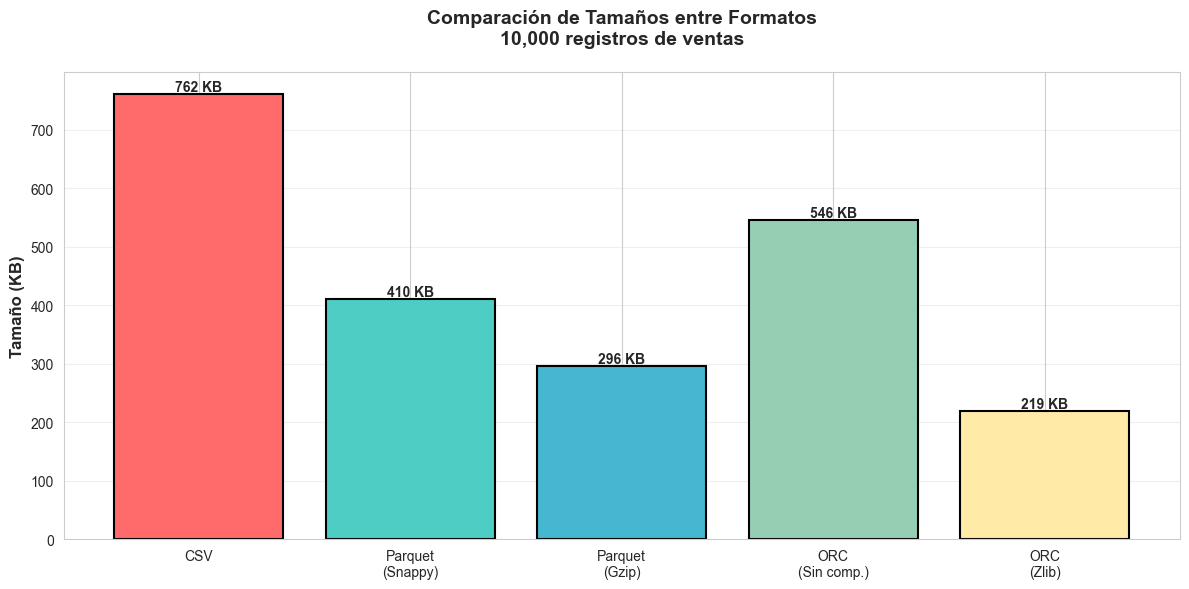


Resumen:
   Mucha compresión: Parquet Gzip (296 KB)
   Mejor balance: Parquet Snappy (410 KB)
   ORC (sin comp.): 546 KB
  Mejor compresión ORC (zlib): 219 KB


In [26]:
# Recopilar información
formatos = {
    'CSV': os.path.getsize('ventas.csv'),
    'Parquet\n(Snappy)': os.path.getsize('ventas.parquet'),
    'Parquet\n(Gzip)': os.path.getsize('ventas_gzip.parquet'),
}

# Añadir ORC si está disponible
if 'orc_available' in globals() and orc_available:
    formatos['ORC\n(Sin comp.)'] = os.path.getsize('ventas.orc')
    formatos['ORC\n(Zlib)'] = os.path.getsize('ventas_zlib.orc')

# Crear gráfico
fig, ax = plt.subplots(figsize=(12, 6))
nombres = list(formatos.keys())
tamaños = [v / 1024 for v in formatos.values()]  # Convertir a KB

colores = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7'][:len(formatos)]
bars = ax.bar(nombres, tamaños, color=colores, edgecolor='black', linewidth=1.5)

# Añadir valores en las barras
for bar, tamaño in zip(bars, tamaños):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{tamaño:.0f} KB',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_ylabel('Tamaño (KB)', fontsize=12, fontweight='bold')
ax.set_title('Comparación de Tamaños entre Formatos\n10,000 registros de ventas', 
             fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nResumen:")
print(f"   Mucha compresión: Parquet Gzip ({os.path.getsize('ventas_gzip.parquet')/1024:.0f} KB)")
print(f"   Mejor balance: Parquet Snappy ({os.path.getsize('ventas.parquet')/1024:.0f} KB)")
if 'orc_available' in globals() and orc_available:
    print(f"   ORC (sin comp.): {os.path.getsize('ventas.orc')/1024:.0f} KB")
    print(f"  Mejor compresión ORC (zlib): {os.path.getsize('ventas_zlib.orc')/1024:.0f} KB")


## Conclusiones y Recomendaciones

### Cuándo usar cada formato:

**CSV**:
- Intercambio simple de datos
- Legibilidad humana
- No eficiente para grandes volúmenes

**Avro**:
- Streaming de datos (Kafka)
- Evolución de esquemas
- Escrituras frecuentes
- Datos orientados a filas

**Parquet**:
- Analítica de datos con Spark
- Consultas sobre subconjunto de columnas
- Máxima compresión
- Data warehouses y data lakes

**ORC**:
- Ecosistema Hadoop/Hive
- Consultas OLAP
- Alta compresión con índices

### Tabla comparativa:

| Característica | CSV | Avro | Parquet | ORC |
|----------------|-----|------|---------|-----|
| Tipo | Texto | Binario/Filas | Binario/Columnar | Binario/Columnar |
| Compresión | Baja | Media | Alta | Alta |
| Velocidad lectura | Lenta | Media | Rápida | Rápida |
| Evolución esquema | No | Sí | Sí | Sí |
| Mejor para | Intercambio | Streaming | Analítica | Hive/Hadoop |

### Comparación de rendimiento según la web:

Según el artículo de [Aitor Medrano](https://aitor-medrano.github.io/iabd/de/formatos.html), con datos de ventas de Alemania:

- **CSV**: 9.7 MiB
- **Avro**: 6.9 MiB
  - Avro con Gzip: 1.9 MiB
  - Avro con Snappy: 2.8 MiB
- **Parquet**: 2.3 MiB
  - Parquet con Gzip: 1.6 MiB
  - Parquet con Snappy: 2.3 MiB
- **ORC**: 6.98 MiB

**Conclusión**: Parquet con Gzip ofrece la mejor compresión (83% de ahorro vs CSV)


---

# EJERCICIOS PRÁCTICOS

Estos ejercicios te ayudarán a dominar los formatos de datos.


## Ejercicio 1: El Reto de la Compresión

**Objetivo**: Descubre qué formato y compresión es más eficiente para diferentes tipos de datos.

**Tarea**:
1. Genera un dataset de 50,000 registros de transacciones de comercio electrónico con:
   - ID de transacción
   - Fecha y hora
   - Producto (10 productos diferentes)
   - Categoría (5 categorías)
   - Precio
   - Cantidad
   - Cliente ID
   - País (15 países)

2. Guarda los datos en:
   - CSV
   - Avro (sin compresión, snappy, deflate)
   - Parquet (snappy, gzip, brotli)
   - ORC (sin compresión, zlib)

3. Crea una tabla comparativa y un gráfico de barras con los tamaños

4. **BONUS**: Calcula el ratio de compresión para cada formato


In [16]:
# Pista: Usa Faker para generar datos realistas
# Pista 2: Usa time.time() para medir tiempos de escritura




## Ejercicio 2: La Carrera de la Velocidad

**Objetivo**: Compara la velocidad de lectura entre formatos para diferentes tipos de consultas.

**Tarea**:
1. Usa el dataset del Ejercicio 1

2. Realiza las siguientes operaciones y mide el tiempo:
   - Lectura completa del archivo
   - Lectura de solo 2 columnas
   - Lectura con filtro (ej: país = 'España')
   - Lectura de las primeras 1000 filas

3. Compara CSV, Parquet y ORC

4. Crea un gráfico de barras agrupadas mostrando los tiempos

5. **BONUS**: ¿Qué formato es mejor para qué tipo de consulta? Justifica.


In [17]:

# Pista: Para Parquet puedes usar columns=['col1', 'col2'] en read_parquet
# Pista 2: Para CSV usa usecols=['col1', 'col2'] en read_csv




## Ejercicio 3: Esquemas Avro Avanzados

**Objetivo**: Domina la creación de esquemas Avro complejos.

**Tarea**:
1. Crea un esquema Avro para un sistema de gestión de biblioteca que incluya:
   - **Libro**: título, ISBN, año de publicación, géneros (array), precio
   - **Autor**: nombre completo, fecha de nacimiento, nacionalidad
   - **Editorial**: nombre, país
   - **Préstamo**: fecha de préstamo, fecha de devolución (puede ser null), usuario ID

2. El esquema debe tener estructuras anidadas (record dentro de record)

3. Genera 100 registros de ejemplo con datos realistas

4. Guarda los datos en Avro con compresión Snappy

5. Lee los datos y muestra:
   - Los 5 libros más caros
   - Los préstamos que aún no se han devuelto
   - Distribución de libros por género

6. **BONUS**: Modifica el esquema para añadir un campo 'valoración' (evolución de esquema)


In [18]:

# Pista: Para campos anidados usa 'type': 'record'
# Pista 2: Para campos opcionales usa 'type': ['null', 'tipo']




## Ejercicio 4: Análisis con Parquet Particionado

**Objetivo**: Aprende a trabajar con datasets particionados para mejorar el rendimiento.

**Tarea**:
1. Genera un dataset de 100,000 registros de logs de servidor web:
   - Timestamp
   - IP del cliente
   - Método HTTP (GET, POST, PUT, DELETE)
   - URL solicitada
   - Código de estado (200, 404, 500, etc.)
   - Tiempo de respuesta (ms)
   - User agent

2. Guarda el dataset particionado por:
   - Año, mes y día (en carpetas separadas)

3. Realiza consultas optimizadas:
   - Todos los logs de un día específico
   - Errores 500 del último mes
   - URLs más lentas (mayor tiempo de respuesta)

4. Compara el tiempo de lectura con y sin particionado

5. **BONUS**: Crea un dashboard con matplotlib mostrando:
   - Distribución de códigos de estado
   - Tiempo de respuesta promedio por hora
   - Top 10 URLs más solicitadas


In [19]:
# Pista: Usa df.to_parquet('ruta/', partition_cols=['año', 'mes', 'día'])
# Pista 2: Para leer particiones específicas usa filtros de PyArrow




## Ejercicio 5: Proyecto Integrador - Sistema de Streaming de Datos **OPCIONAL**

**Objetivo**: Simula un pipeline completo de datos usando diferentes formatos.

**Escenario**: Eres ingeniero de datos en una empresa de IoT que monitoriza sensores de temperatura en edificios.

**Tarea**:
1. **Ingesta** (Avro): Simula 10,000 lecturas de sensores con:
   - Sensor ID
   - Timestamp
   - Temperatura
   - Humedad
   - Edificio ID
   - Planta
   Guarda en formato Avro (formato de streaming)

2. **Procesamiento**: Lee desde Avro, añade columnas calculadas:
   - Alerta de temperatura (>30°C o <15°C)
   - Rango de confort (basado en temperatura y humedad)
   - Hora del día (mañana, tarde, noche)

3. **Almacenamiento Analítico** (Parquet): 
   - Guarda los datos procesados en Parquet particionado por edificio y fecha
   - Usa compresión Snappy

4. **Reporting** (ORC):
   - Crea agregaciones por edificio y hora
   - Guarda en ORC para consultas con Hive

5. **Análisis**: Responde:
   - ¿Qué edificio tiene más alertas?
   - ¿En qué horario hay más problemas de temperatura?
   - ¿Cuál es la temperatura promedio por planta?

6. **Visualización**: Crea un dashboard con:
   - Serie temporal de temperatura promedio
   - Heatmap de alertas por edificio y hora
   - Distribución de lecturas por rango de confort

7. **BONUS**: Compara el tamaño total del pipeline:
   - Raw data (Avro)
   - Processed data (Parquet)
   - Aggregated data (ORC)
   ¿Cuánto espacio ahorraste con el formato columnar?


In [ ]:
# TU CÓDIGO AQUÍ - FASE 1: INGESTA
# Generar datos de sensores IoT
#HAY UN FALLO QUE TENEIS QUE SOLUCIONAR




✓ Dataset generado: 10000 registros

Primeros registros:
    sensor_id           timestamp  temperatura  humedad edificio_id  planta
0  SENSOR_004 2024-01-01 00:00:00        23.49    48.62           A       3
1  SENSOR_008 2024-01-01 00:15:00        23.94    65.23           B       2
2  SENSOR_004 2024-01-01 00:30:00        21.30    47.66           E       1
3  SENSOR_019 2024-01-01 00:45:00        26.74    57.67           D       1
4  SENSOR_001 2024-01-01 01:00:00        20.59    55.43           A       2


ValueError: snappy codec is supported but you need to install one of the following libraries: ('cramjam',)

In [ ]:
# TU CÓDIGO AQUÍ - FASE 2: PROCESAMIENTO
# Leer desde Avro y añadir columnas calculadas





Leyendo datos desde Avro...


ValueError: snappy codec is supported but you need to install one of the following libraries: ('cramjam',)

In [ ]:
# TU CÓDIGO AQUÍ - FASE 3: ALMACENAMIENTO Y ANÁLISIS

# ===== ALMACENAMIENTO EN PARQUET PARTICIONADO =====




FASE 3: ALMACENAMIENTO Y ANÁLISIS


NameError: name 'df_procesados' is not defined

## Ejercicio 6: Challenge Avanzado - Optimización de Data Lake **OPCIONAL**

**Objetivo**: Simula un problema real de optimización de almacenamiento.

**Escenario**: Tu empresa tiene un data lake con 1 año de datos de transacciones (simula 500,000 registros). Actualmente todo está en CSV y el espacio en disco es un problema.

**Tarea**:
1. Genera el dataset de transacciones con:
   - Fecha (1 año completo)
   - Cliente ID
   - Producto
   - Categoría
   - Precio
   - Cantidad
   - País
   - Método de pago
   - Estado del pedido

2. **Análisis inicial**:
   - Tamaño total en CSV
   - Tiempo de lectura para query típica
   - Memoria consumida

3. **Propón 3 estrategias de optimización**:
   - Estrategia 1: Cambiar a Parquet sin más
   - Estrategia 2: Parquet particionado por mes
   - Estrategia 3: Parquet particionado por país y mes con compresión gzip

4. **Implementa las 3 estrategias** y compara:
   - Espacio en disco
   - Tiempo de lectura completa
   - Tiempo de lectura filtrada (último mes, país específico)
   - Facilidad de mantenimiento

5. **Reporta tus hallazgos**:
   - Tabla comparativa
   - Gráficos de barras
   - Recomendación final justificada

6. **BONUS**: Calcula el ROI (ahorro anual en costos de almacenamiento asumiendo $0.023 por GB/mes en AWS S3)


In [34]:
# EJERCICIO 6: Challenge Avanzado - Optimización de Data Lake
# Sistema completo de optimización de almacenamiento

import shutil

print("=" * 80)
print("EJERCICIO 6: OPTIMIZACIÓN DE DATA LAKE")
print("=" * 80)

# ===== 1. GENERAR DATASET DE 500,000 REGISTROS =====
print("\n1. GENERANDO DATASET DE TRANSACCIONES...")

# Parámetros
n_transacciones = 500000
productos = ['Laptop', 'Monitor', 'Teclado', 'Ratón', 'Webcam', 'Auriculares', 'Hub USB', 'SSD', 'RAM', 'Placa Base']
categorias = ['Electrónica', 'Accesorios', 'Almacenamiento', 'Componentes', 'Periféricos']
países = ['España', 'Portugal', 'Francia', 'Italia', 'Alemania', 'Reino Unido', 'Holanda', 'Bélgica', 
          'Polonia', 'Suecia', 'Noruega', 'Dinamarca', 'Finlandia', 'Austria', 'Grecia']
metodos_pago = ['Tarjeta', 'Transferencia', 'PayPal', 'Crypto']
estados = ['Pendiente', 'Procesando', 'Enviado', 'Entregado', 'Devuelto']

np.random.seed(42)
random.seed(42)

transacciones = {
    'id_transaccion': [f"TRX_{i:08d}" for i in range(n_transacciones)],
    'fecha': pd.date_range('2023-01-01', periods=n_transacciones, freq='1H'),
    'cliente_id': np.random.randint(1000, 50000, n_transacciones),
    'producto': np.random.choice(productos, n_transacciones),
    'categoria': np.random.choice(categorias, n_transacciones),
    'precio': np.random.uniform(10, 2000, n_transacciones).round(2),
    'cantidad': np.random.randint(1, 10, n_transacciones),
    'pais': np.random.choice(países, n_transacciones),
    'metodo_pago': np.random.choice(metodos_pago, n_transacciones),
    'estado': np.random.choice(estados, n_transacciones)
}

df_transacciones = pd.DataFrame(transacciones)
df_transacciones['total'] = (df_transacciones['precio'] * df_transacciones['cantidad']).round(2)

print(f"✓ Dataset generado: {len(df_transacciones):,} registros")
print(f"Período: {df_transacciones['fecha'].min()} a {df_transacciones['fecha'].max()}")





EJERCICIO 6: OPTIMIZACIÓN DE DATA LAKE

1. GENERANDO DATASET DE TRANSACCIONES...


C:\Users\Giralte\AppData\Local\Temp\ipykernel_14124\1690848416.py:27: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  'fecha': pd.date_range('2023-01-01', periods=n_transacciones, freq='1H'),


✓ Dataset generado: 500,000 registros
Período: 2023-01-01 00:00:00 a 2080-01-15 07:00:00


---

## Recursos Adicionales

### Documentación oficial:
- [Apache Avro](https://avro.apache.org/)
- [Apache Parquet](https://parquet.apache.org/)
- [Apache ORC](https://orc.apache.org/)
- [PyArrow Documentation](https://arrow.apache.org/docs/python/)
- [Pandas I/O tools](https://pandas.pydata.org/docs/user_guide/io.html)

### Artículos recomendados:
- [Choosing Between Row and Column Oriented Data Storage](https://towardsdatascience.com/choosing-between-row-and-column-oriented-data-storage-8b54f3e0d9b)
- [Parquet vs ORC vs Avro: Choosing the Right Format](https://luminousmen.com/post/big-data-file-formats)

### Para profundizar:
- [Experimenta con datasets reales de Kaggle](https://www.kaggle.com/)
- [Experimenta con datos abiertos reales de España](https://datos.gob.es/es/iniciativas)
- Prueba integración con Apache Spark
- Explora AWS Athena para queries sobre Parquet

---



*El mejor ingeniero de datos no es el que conoce todos los formatos, sino el que sabe cuál usar en cada situación.*



---

## TEORÍA AVANZADA: Compresión, Entropía y Patrones

### Teorema de Shannon: Límites de la Compresión

Claude Shannon demostró que existe un límite teórico para la compresión llamado "entropía":

**Definición**: La entropía es la cantidad mínima de información requerida para codificar datos.

**Fórmula**: H = -Σ (p_i * log2(p_i))

Donde p_i es la probabilidad de cada símbolo.

**Ejemplo práctico**:
```
Datos: AAABBBCCCC (10 caracteres)
Probabilidades:
  A aparece 3/10 = 30%
  B aparece 3/10 = 30%
  C aparece 4/10 = 40%

Entropía = -((0.3 * log2(0.3)) + (0.3 * log2(0.3)) + (0.4 * log2(0.4)))
        = 1.57 bits por símbolo

INTERPRETACIÓN:
- Sin compresión: 10 caracteres * 8 bits = 80 bits
- Teórico mínimo (Shannon): 10 * 1.57 = 15.7 bits
- Compresión teórica máxima: 80.3%

La realidad alcanza 70-80% porque los algoritmos no son perfectos
```

**Importancia práctica**:
- Datos muy uniformes (muchos repetidos): Alta compresión posible
- Datos muy aleatorios: Baja compresión posible
- Parquet explota esto: agrupa datos similares para mayor entropía

### Diccionarios y Codificación Run-Length

Parquet usa varias técnicas:

**1. Diccionarios (para columnas con pocos valores únicos)**:
```
Datos originales:
["IT", "IT", "HR", "IT", "Sales", "HR", "IT", "Sales", "IT"]

Diccionario:
0 → "IT"
1 → "HR"
2 → "Sales"

Comprimido:
[0, 0, 1, 0, 2, 1, 0, 2, 0]

Ahorro: 9 strings (40 bytes) → 9 números (36 bytes) = 10% + más compresión posible
```

**2. Run-Length Encoding**:
```
Datos: AAAABBBCCCCCC

Almacenado como:
(4, A), (3, B), (6, C)

6 caracteres → 3 códigos = 50% compresión

Ideal para: Datos con muchos valores repetidos consecutivos
```

**3. Delta Encoding (para series de números)**:
```
Datos: [1000, 1005, 1003, 1008, 1002]

Diferencias (deltas):
[1000, 5, -2, 5, -6]

Números más pequeños se comprimen mejor
Los números pequeños tienen menos bits

Ejemplo con variable-length int:
1000 necesita 2 bytes
5 necesita 1 byte
-2 necesita 1 byte
```

### Índices y Metadatos

Parquet mantiene dos tipos de metadatos:

**1. Estadísticas (por Row Group)**:
```json
{
  "row_group": 1,
  "columns": {
    "salario": {
      "min": 10000,
      "max": 99999,
      "null_count": 15,
      "distinct_count": 45678
    }
  }
}
```

**Uso**: Si ejecutas `WHERE salario > 150000`, Parquet ve que max(salario)=99999
       → Salta este Row Group completamente

**2. Índices Page-Level**:
```
Parquet divide Column Chunks en Páginas:
├── Page 1 (filas 1-1000): min=100, max=5000
├── Page 2 (filas 1001-2000): min=4500, max=9000
├── Page 3 (filas 2001-3000): min=8000, max=15000
```

Si buscas `salario > 10000`, necesitas solo Página 3

**Beneficio**: Queries 100x más rápidas por evitar lecturas innecesarias

### Compresión vs Descompresión: Trade-off

```
                SNAPPY  GZIP   LZ4    BROTLI
Compresión      70%     80%    60%    85%
Velocidad       Fast    Slow   VeryFast Medium
CPU uso         Low     High   Low    High

CASO DE USO 1: Datos en tránsito (red)
→ LZ4 (muy rápido, puede recomprimir)

CASO DE USO 2: Datos que no se leen mucho
→ GZIP (máxima compresión, leer es raro)

CASO DE USO 3: Balance (data lakes, consultas frecuentes)
→ SNAPPY (velocidad + compresión decente)

CASO DE USO 4: Máxima compresión futura (Brotli)
→ BROTLI (mejor compresión, pero implementación limitada)
```


---

## ORGANIZACIÓN DE DATOS: Particionado y Bucketing

### Particionado: Divide et Impera

**Concepto**: Dividir datos en directorios basados en una columna

**Ejemplo**:
```
Sin particionado:
datos.parquet (5TB) ← Un archivo GIGANTE

Con particionado:
datos/
  └── año=2023/
      └── mes=1/
          ├── file_001.parquet (50MB)
          ├── file_002.parquet (50MB)
          └── ...
      └── mes=2/
          ├── file_001.parquet (50MB)
          └── ...
  └── año=2024/
      └── mes=1/
          ├── file_001.parquet (50MB)
          └── ...
```

**Ventajas**:
1. **Partition Pruning**: Si preguntas por 2024/mes=3, ¡ignora 2023 completamente!
2. **Paralelismo**: Spark puede procesar cada partición en paralelo
3. **Mantenimiento**: Agregar datos nuevos = crear carpeta nueva (sin tocar antiguos)

**Fórmula de beneficio**:
```
Sin particionado: 2024 años * 12 meses * 50GB/mes = 1,200 GB para leer TODO
Con particionado: 1 mes * 50GB = 50GB (24x más rápido!)
```

**Cuándo particionar**:
- Datos con dimensión temporal (fecha, hora)
- Datos geográficos (país, región)
- Datos categóricos con pocos valores (género, estado)
- NO particionar por columna de alta cardinalidad (UUID: crearías millones de carpetas)

### Bucketing: Organización Más Avanzada

**Concepto**: Subdividir datos dentro de una partición basado en hash

**Ejemplo**:
```
Sin bucketing:
datos/año=2024/mes=1/
  ├── file_001.parquet (50MB)
  ├── file_002.parquet (50MB)
  └── ...

Con bucketing (4 buckets basado en user_id):
datos/año=2024/mes=1/
  ├── bucket_0/ (user_id % 4 == 0): 12.5MB
  ├── bucket_1/ (user_id % 4 == 1): 12.5MB
  ├── bucket_2/ (user_id % 4 == 2): 12.5MB
  └── bucket_3/ (user_id % 4 == 3): 12.5MB
```

**Ventajas**:
1. **Join Optimization**: Si dos tablas están bucketadas por user_id, Spark puede hacer join directo (sin shuffle)
2. **Distribución uniforme**: Evita "hot partitions" (algunos archivos mucho más grandes)

**Fórmula de beneficio**:
```
Sin bucketing, Join:
  Tabla A (100GB) × Tabla B (100GB)
  → Shuffle completo: 200GB en red (LENTO)

Con bucketing:
  Bucket A_0 (25GB) × Bucket B_0 (25GB) en paralelo
  → Shuffle: 0GB en red (cada worker trabaja localmente)
  → 100x más rápido
```

**Trade-off**:
```
Particionado:
+ Fácil de entender
+ Partition pruning automático
- Muchas particiones = overhead metadatos

Bucketing:
+ Optimiza joins específicos
+ Distribución uniforme
- Más complejo
- Necesita que Spark entienda bucketing
```

### Particionado Adaptativo (Adaptive Partitioning)

Los sistemas modernos (Spark 3.0+) usan "particionado adaptativo":

**Problema antiguo**:
```
Especificas: partition_cols=['fecha']
Resultado:
  Enero = 1 carpeta (1GB)
  Febrero = 1 carpeta (50GB)
  Marzo = 1 carpeta (1GB)

PROBLEMA: Febrero es 50x más grande (desequilibrio)
```

**Solución moderna (Adaptive Partitioning)**:
```
Spark detecta desequilibrio:
  Febrero muy grande → Lo divide en:
    ├── fecha=2024-02-01_to_07 (7GB)
    ├── fecha=2024-02-08_to_14 (7GB)
    ├── fecha=2024-02-15_to_21 (7GB)
    ├── fecha=2024-02-22_to_28 (7GB)
    └── fecha=2024-02-29 (1GB)

RESULTADO: Todas las carpetas ~7GB (equilibrio)
```

**Beneficio**: Paralelismo perfecto sin overhead manual
